# Business Idea Evaluator

### Import Modules

In [ ]:
from dotenv import load_dotenv
import os
import operator

from typing import TypedDict, List, Annotated, Dict, Literal

from openai import OpenAI
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, BaseMessage

from langgraph.graph.message import add_messages
from langgraph.graph import START, END, StateGraph, MessagesState
from langgraph.checkpoint.memory import InMemorySaver

from pydantic import BaseModel, Field

from IPython.display import Image, display, Markdown

### Load API Keys

In [6]:
# Please make sure to create a .env file in the root directory of the project and add your OpenAI API key as follows:
# OPENAI_API_KEY="<your_openai_api_key_here>"

# Please make sure to create a .env file in the root directory of the project and add your LangSmith API key as follows:
# LANGCHAIN_API_KEY="<your_langsmith_api_key_here>"
# LANGSMITH_API_KEY="<your_langsmith_api_key_here>"
# LANGSMITH_TRACING=<true_or_false>
# LANGCHAIN_TRACING_V2=<true_or_false>
# LANGSMITH_ENDPOINT="<your_langsmith_endpoint_here>" (if using a custom endpoint, otherwise it defaults to https://api.smith.langchain.com)
# LANGSMITH_PROJECT="<your_agent_name_here>"

load_dotenv()

True

## Initialization

In [7]:
# create a LLM Model with 0 temperature, since it is an advisor for business idea.

llm = ChatOpenAI(
    model = "gpt-5.4-mini",
    temperature = 0
)

In [8]:
class State(TypedDict):
    idea: str
    messages: Annotated[List[BaseMessage], add_messages]
    advisor_reports: Annotated[Dict[str, str], operator.or_]
    final_report: str
    

## Building Human-in-the-Loop (HITL)

In [9]:
system_message = SystemMessage(content = """
                               
                               You are a helpful tool that evaluates business ideas.
                               
                               Your task is to decide whether you have enough information about the business ideas.
                               
                               If not, ask One precise follow-up question to get more information about the business idea. Do not ask more than one question at a time. 
                               If yes, say: DONE
                               
                               """)

In [10]:
def assistant(state: State) -> State:
    
    response = llm.invoke([system_message] + state["messages"])
    
    return State(messages = [response])

In [11]:
def routing_function(state: State) -> Literal['advisors_start_node', 'ask_user_node']:
    
    if state["messages"][-1].content.strip().upper().startswith("DONE"):
        
        return "advisors_start_node"
    
    else:
        
        return "ask_user_node"

In [12]:
def ask_user_node(state: State) -> State:
    
    question = state["messages"][-1].content
    
    print(f"\n\n Assistant : {question} \n\n")
    
    human_message = HumanMessage(content = input("You: "))
    
    new_messages = state["messages"] + [human_message]
    
    return State(messages = new_messages, human_advisor_feedback = human_message.content)
    
    

## Build Expert Advisors

In [13]:
def market_analyst_advisor(state: State) -> State:
    
    prompt = f"""
    
    You are a helpful senior MARKET ANALYST that gets an idea as an input. You need to evaluate the market potential, competition, target customers.
    Conduct market sizing and competitor analysis research for the business idea.
    Identify target customer segments and their needs.
    Provide insights on market trends and dynamics that could impact the success of the business idea.
    Assess timing, trends, and macroeconomic factors that could influence the business idea's success.
    Provide a comprehensive report on the market potential of the business idea, including opportunities and challenges.
    
    Idea: 
    {state["messages"]}
    
    """
    
    advisor_report = llm.invoke([SystemMessage(content = prompt)])
    
    return State(advisor_reports = {"market_analyst": advisor_report.content})

In [14]:
def legal_advisor(state: State) -> State:
    
    prompt = f"""
    
    You are a helpful senior LEGAL ADVISOR that gets an idea as an input. You need to evaluate the legal aspects of the business idea.
    Identify potential legal risks, regulatory requirements, and compliance issues.
    Assess intellectual property considerations, including patents, trademarks, and copyrights.
    Evaluate liability concerns and suggest appropriate legal structures for the business.
    Analyze industry-specific regulations and licensing requirements.
    Provide a comprehensive report on the legal landscape, including potential challenges and recommendations.
    
    Idea: 
    {state["messages"]}
    
    """
    
    advisor_report = llm.invoke([SystemMessage(content = prompt)])
    
    return State(advisor_reports = {"legal_advisor": advisor_report.content})

In [15]:
def technical_advisor(state: State) -> State:
    
    prompt = f"""
    
    You are a helpful senior TECHNICAL ADVISOR that gets an idea as an input. You need to evaluate the technical feasibility of the business idea.
    Assess the technology stack required to build and scale the product or service.
    Identify technical challenges, risks, and dependencies.
    Evaluate the development timeline, resource requirements, and infrastructure needs.
    Analyze scalability, security, and performance considerations.
    Provide a comprehensive report on the technical viability of the business idea, including recommendations and potential roadblocks.
    
    Idea: 
    {state["messages"]}
    
    """
    
    advisor_report = llm.invoke([SystemMessage(content = prompt)])
    
    return State(advisor_reports = {"technical_advisor": advisor_report.content})

In [16]:
def strategist_advisor(state: State) -> State:
    
    prompt = f"""
    
    You are a helpful senior BUSINESS STRATEGIST that gets an idea as an input. You need to evaluate the strategic viability of the business idea.
    Assess the business model, revenue streams, and monetization strategies.
    Evaluate the go-to-market strategy, partnerships, and distribution channels.
    Identify competitive advantages, differentiation factors, and barriers to entry.
    Analyze growth potential, scalability of the business model, and long-term sustainability.
    Provide a comprehensive report on the strategic outlook of the business idea, including actionable recommendations and key success factors.
    
    Idea: 
    {state["messages"]}
    
    """
    
    advisor_report = llm.invoke([SystemMessage(content = prompt)])
    
    return State(advisor_reports = {"strategist_advisor": advisor_report.content})

## Building Graph

In [17]:
def final_report_consultant(state: State) -> State:
    
    if len(state["advisor_reports"]) < 4:
        return {}
    
    report_prompt = f"""
    
    You are a senior consultant that gets 4 reports from different advisors (market analyst, legal advisor, technical advisor, business strategist) as input. 
    Your task is to synthesize the information from these reports and provide a comprehensive evaluation of the business idea.
    Analyze the strengths, weaknesses, opportunities, and threats (SWOT analysis) based on the insights provided by the advisors.
    Provide an overall assessment of the viability and potential success of the business idea.
    
    The 4 advisor reports are as follows:
    {state["advisor_reports"]}
    
    """
    
    final_report = llm.invoke([SystemMessage(content = report_prompt)])
    
    final_report.pretty_print()
    
    return State(final_report = final_report.content)

In [18]:
memory = InMemorySaver()

In [28]:
config = {
    "configurable":{
        "thread_id": "business_idea_evaluation_001"
    }
}

In [20]:
agent_graph = StateGraph(State)

In [21]:
agent_graph.add_node("assistant", assistant)
agent_graph.add_node("ask_user_node", ask_user_node)
agent_graph.add_node("advisors_start_node", lambda state:{})
agent_graph.add_node("market_analyst_advisor", market_analyst_advisor)
agent_graph.add_node("legal_advisor", legal_advisor)
agent_graph.add_node("technical_advisor", technical_advisor)
agent_graph.add_node("strategist_advisor", strategist_advisor)
agent_graph.add_node("final_report_consultant", final_report_consultant)

In [22]:
agent_graph.add_edge(START, "assistant")
agent_graph.add_conditional_edges(source = "assistant", 
                                 path = routing_function)
agent_graph.add_edge("ask_user_node", "assistant")
agent_graph.add_edge("advisors_start_node", "market_analyst_advisor")
agent_graph.add_edge("advisors_start_node", "legal_advisor")
agent_graph.add_edge("advisors_start_node", "technical_advisor")
agent_graph.add_edge("advisors_start_node", "strategist_advisor")

agent_graph.add_edge("market_analyst_advisor", "final_report_consultant")
agent_graph.add_edge("legal_advisor", "final_report_consultant")
agent_graph.add_edge("technical_advisor", "final_report_consultant")
agent_graph.add_edge("strategist_advisor", "final_report_consultant")

agent_graph.add_edge("final_report_consultant", END)


In [26]:
agent_graph_runnable = agent_graph.compile(memory)

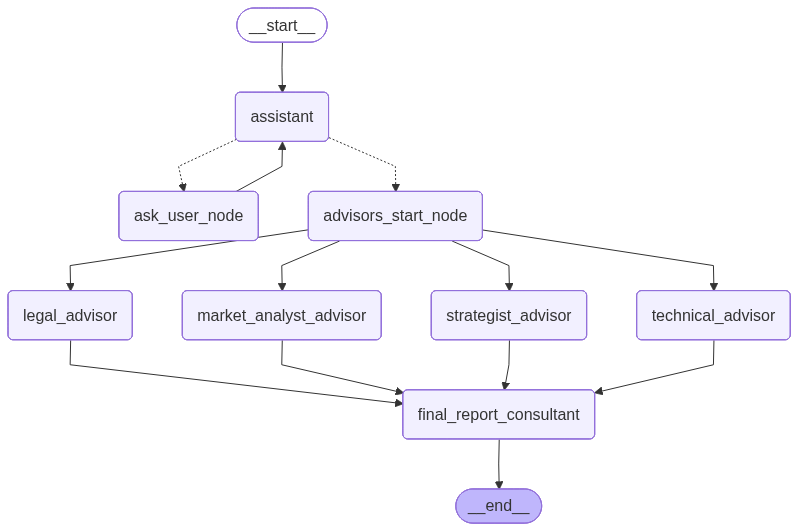

In [27]:
agent_graph_runnable

## Test the agent AI

In [ ]:
print("What is your business idea?")

idea = input("You: ")

initial_state = State(idea = idea, 
                      messages = [HumanMessage(content = idea)], 
                      advisor_reports = {}, 
                      final_report = "")

report = agent_graph_runnable.invoke(initial_state, config = config)

What is your business idea?


 Assistant : What specific type of commercial short videos do you want to generate, and for which target customers or industry? 




 Assistant : What industry or product category is the advertisement for? 


================================== Ai Message ==================================

## Comprehensive Evaluation: AI-Generated Commercial Short Videos for Many Product Categories

### Overall Summary
This is a **promising but execution-sensitive business idea**. The market demand is real: advertisers increasingly need **fast, low-cost, high-volume short-form video ads** for TikTok, Reels, Shorts, and paid social. AI is now good enough to support meaningful parts of the workflow, especially script generation, templated editing, voiceovers, localization, and variation generation.

However, the idea becomes much riskier when framed as **“all kinds of products”**. The legal, compliance, and technical burden rises sharply for regulated categories like health,

{'idea': 'My idea is to use AI to generate commercial short videos.',
 'messages': [HumanMessage(content='My idea is to use AI to generate commercial short videos.', additional_kwargs={}, response_metadata={}, id='1d785ec4-d95d-46c9-9505-bc7d1e570108'),
  AIMessage(content='What specific type of commercial short videos do you want to generate, and for which target customers or industry?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 90, 'total_tokens': 114, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DbDxXMzLF3YtFcmbthAmdrjSJ13jL', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019deb00-697b-7b60-ba3f-255e430ae8b